# Venture Insights — Customer Segmentation 

Categorical segmentation of 3,030 casino-machine accounts using **K-Modes (K=5)**, validated
with Gower distance, MCA/PCoA visualization, profiled-only structural validation, a multi-method
outlier framework, and a 36-check solution-validation framework.

**Run requirements:**: Place `Clustering_Data.ftr` (and optionally the data dictionary) in the
same folder as this notebook. All randomness is seeded (`SEED = 42`) for reproducibility.

**Structure** : this notebook is organised so each case-study question has its own clearly
labelled section:

| Q | Ask | Section |
|---|---|---|
| Q1 | Clustering logic/algorithm + cluster–account mapping | §3–§6 |
| Q2 | Feature selection approach + statistical reasoning | 2 |
| Q3 | 2-D visualization of clusters | 7 |
| Q4 | EDA + outlier detection logic/code | 1, 8 |
| Q5 | Data quality issues in the dataset | 9 |
| Q6 | Exhaustive quality-check list to validate the solution | 10 |




In [1]:
# ---------------------------------------------------------------------------
# 0. Setup
# ---------------------------------------------------------------------------
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

from kmodes.kmodes import KModes
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              adjusted_rand_score, normalized_mutual_info_score)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency
from scipy.spatial.distance import squareform
import gower
import prince  # MCA
import openpyxl

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

DATA = 'Clustering_Data.ftr'          # <-- place the file alongside this notebook
MISSING = {'None', '-', '', 'nan', 'NaN', 'No Address Found'}

# Modeling feature set (Q2) -- behaviour/value/opportunity, all categorical/ordinal
CORE = ['Revenue_Bucket', 'Profit_Bucket', 'Market_Share_Segment', 'Market_Potential_Segment',
        'Churn_Segment', 'Propensity', 'Competitiveness_Flag']

# Broader behavioural set used only for EDA / profiled-only mask, not modeling
BEHAV = ['Seasonality_Segment', 'EA_Segment', 'Revenue_Bucket', 'Profit_Bucket',
         'Market_Share_Segment', 'Casino_Size_Segment', 'Market_Potential_Segment', 'Churn_Segment']

# Ordinal encodings, used ONLY for Gower distance validation / Davies-Bouldin -- K-Modes itself
# uses category matching and does not require an ordering.
ORD = {'Revenue_Bucket': {'NP': 0, 'L': 1, 'M': 2, 'H': 3},
       'Profit_Bucket': {'NP': 0, 'L': 1, 'M': 2, 'H': 3},
       'Market_Share_Segment': {'NP': 0, 'L': 1, 'M': 2, 'H': 3},
       'Market_Potential_Segment': {'NP': 0, 'L': 1, 'M': 2, 'H': 3, 'VH': 4},
       'Propensity': {'NP': 0, 'L': 1, 'M': 2, 'H': 3},
       'Churn_Segment': {'NP': 0, 'Concerning': 1, 'Minimal Change': 2, 'Encouraging': 3}}

ORDER = ["High-Potential Growth Champions", "Loyal Profitable Core", "Under-Profiled Active Accounts",
         "Contested-Market Prospects", "Open-Market Prospects"]


## 0. Load & schema validation

Load the feather file and assert the expected shape 

In [2]:
df = pd.read_feather(DATA)
assert df.shape[1] == 18, f"Schema drift: expected 18 columns, got {df.shape[1]}"
assert df['Customer_ID'].is_unique, "Customer_ID is not unique"
print(df.shape)
df.head()


(3030, 18)


,Customer_ID,Street,City,State_Code,Postal_Code,Country,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Share_Segment,Casino_Size_Segment,Market_Potential_Segment,Churn_Segment,Competitiveness_Flag,Volume_Segment,Density_Segment,Propensity
0,Accoount 1,2295 BATTLEFORD RD,MISSISSAUGA,ON,L5N 2W8,CAN,None,None,None,None,None,None,None,None,Yes,High,High,-
1,Accoount 2,64 WESTBANK EXPY STE A,GRETNA,LA,70053,USA,NaN,None,None,None,None,None,None,None,-,Medium,Medium,-
2,Accoount 3,209-229 E Airline Hwy.,LaPlace,LA,70068,USA,None,None,None,None,None,None,None,None,-,Medium,Medium,-
3,Accoount 4,500 S MEADOWS PKWY,RENO,NV,89521,USA,None,None,None,None,None,None,None,None,Yes,High,High,-
4,Accoount 5,746 Victorian Avenue,Sparks,NV,89431,USA,None,None,None,None,None,None,None,None,Yes,High,High,-


## 1. Data cleaning & EDA (Q4 — EDA half)

### 1.1 Normalise the three missing-value encodings
The raw data uses **three different tokens for "absent"**: the literal string `'None'`, true
`NaN`, and the string `'-'`. Any downstream `.isna()` call that doesn't account for this will
under-count missingness — this is Data Quality Issue #2 (§9).

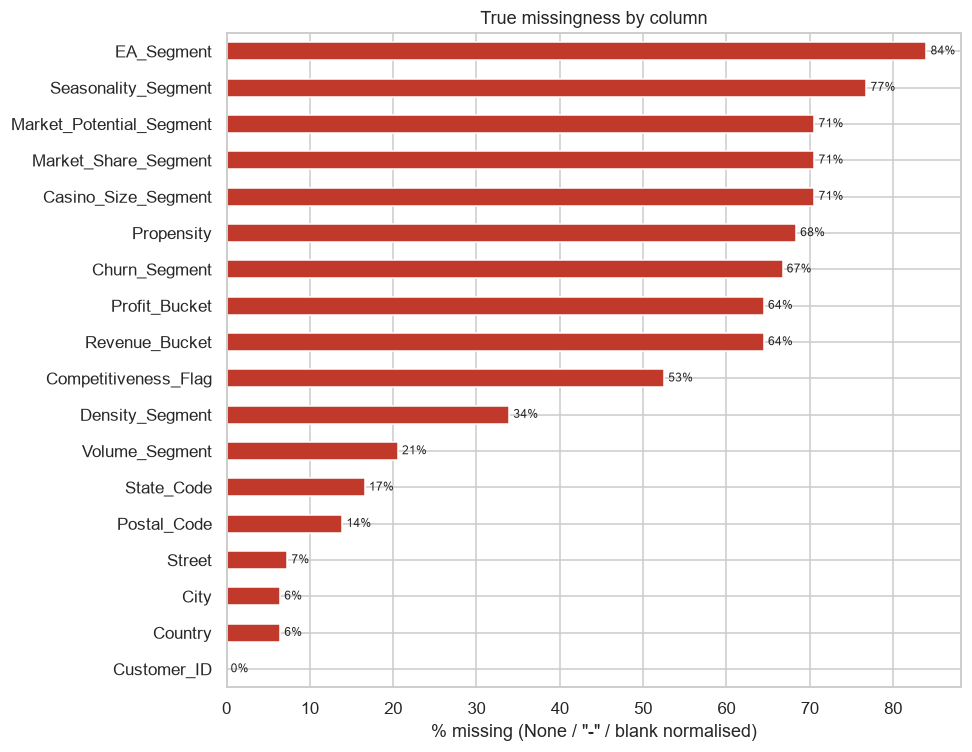

In [3]:
def normalise(frame: pd.DataFrame) -> pd.DataFrame:
    def n(x):
        if pd.isna(x):
            return np.nan
        x = str(x).strip()
        return np.nan if x in MISSING else x
    return frame.apply(lambda c: c.map(n))

clean = normalise(df)

missing_pct = clean.isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(9, 7))
missing_pct.plot(kind='barh', ax=ax, color='#c0392b')
ax.invert_yaxis()
ax.set_xlabel('% missing (None / "-" / blank normalised)')
ax.set_title('True missingness by column')
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()


### 1.2 Univariate distributions
Raw category counts per behavioural/value feature, `NP`/missing included as its own bar so the
scale of "not yet profiled" is visible at a glance rather than hidden by a summary statistic.

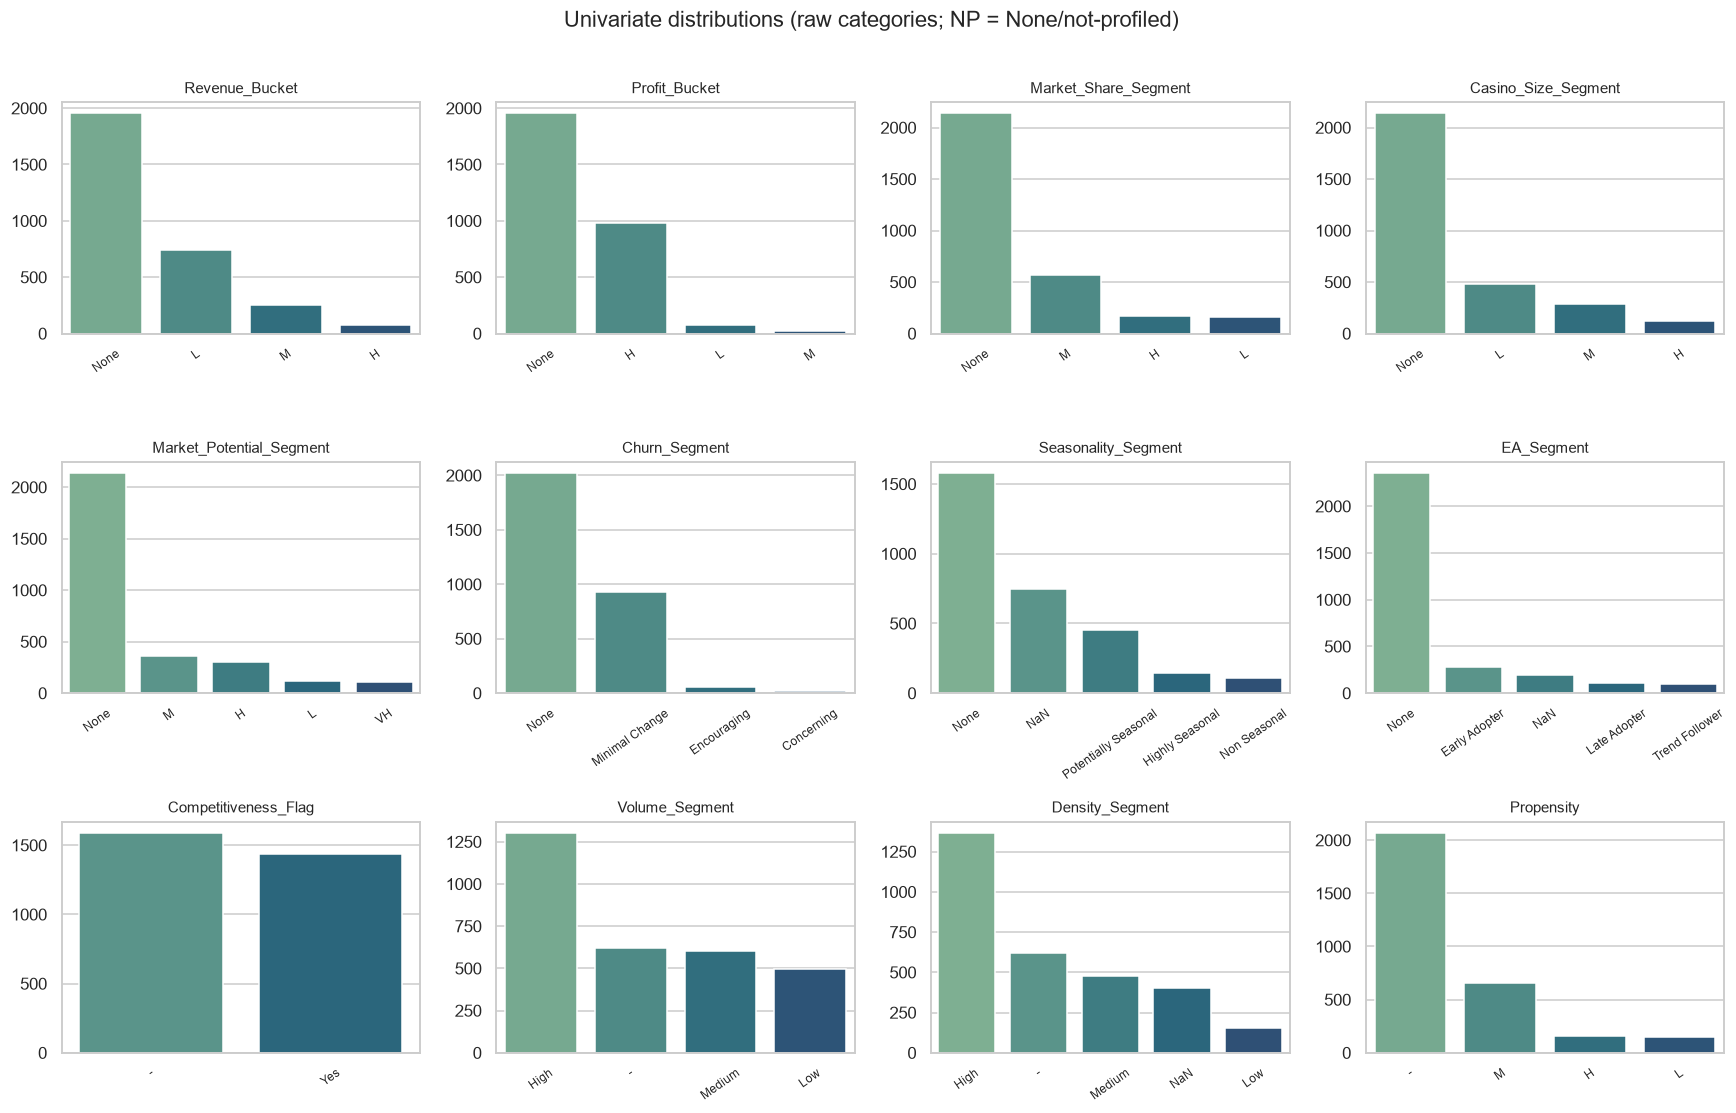

In [4]:
behav_cols = ['Revenue_Bucket', 'Profit_Bucket', 'Market_Share_Segment', 'Casino_Size_Segment',
              'Market_Potential_Segment', 'Churn_Segment', 'Seasonality_Segment', 'EA_Segment',
              'Competitiveness_Flag', 'Volume_Segment', 'Density_Segment', 'Propensity']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, behav_cols):
    vc = df[col].fillna('NaN').astype(str).value_counts()
    sns.barplot(x=vc.index, y=vc.values, ax=ax, palette='crest')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
fig.suptitle('Univariate distributions (raw categories; NP = None/not-profiled)', y=1.01)
plt.tight_layout(); plt.show()


### 1.3 Structured (MNAR) missingness pattern
Do the behavioural columns go missing **together**, or independently? If Revenue and Profit are
always missing on the same rows, that's a strong signal the missingness itself is a business
state ("never transacted") rather than random data loss.

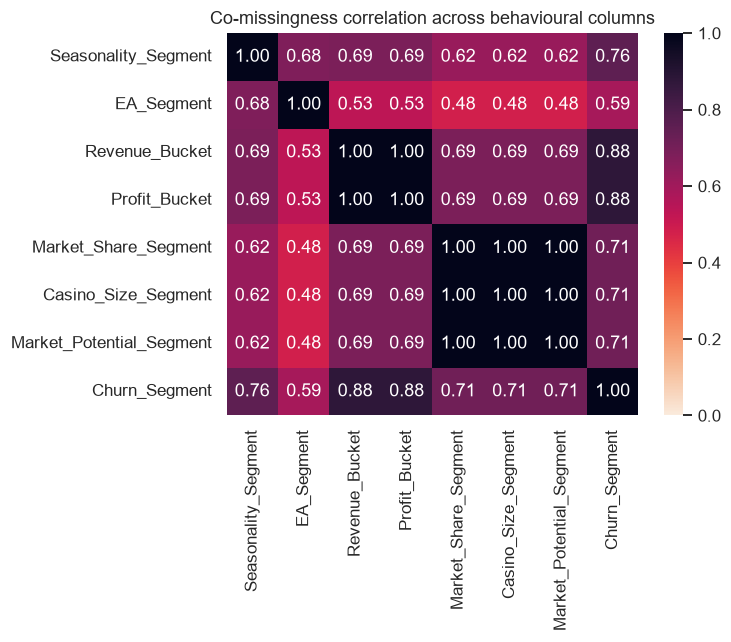

58.7% of accounts have ZERO behavioural data across all 8 columns -> treat as 'prospect', not as a data-quality failure.


In [5]:
co_missing = clean[BEHAV].isna().astype(int)
corr = co_missing.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket_r', vmin=0, vmax=1, ax=ax)
ax.set_title('Co-missingness correlation across behavioural columns')
plt.tight_layout(); plt.show()

pct_never_profiled = (clean[BEHAV].isna().all(axis=1)).mean() * 100
print(f"{pct_never_profiled:.1f}% of accounts have ZERO behavioural data across all {len(BEHAV)} columns"
      " -> treat as 'prospect', not as a data-quality failure.")


### 1.4 Business relationships (row-normalised crosstabs)
A few sanity views on how the buckets relate to each other before they go into a model —
useful both as EDA and as a face-validity check.

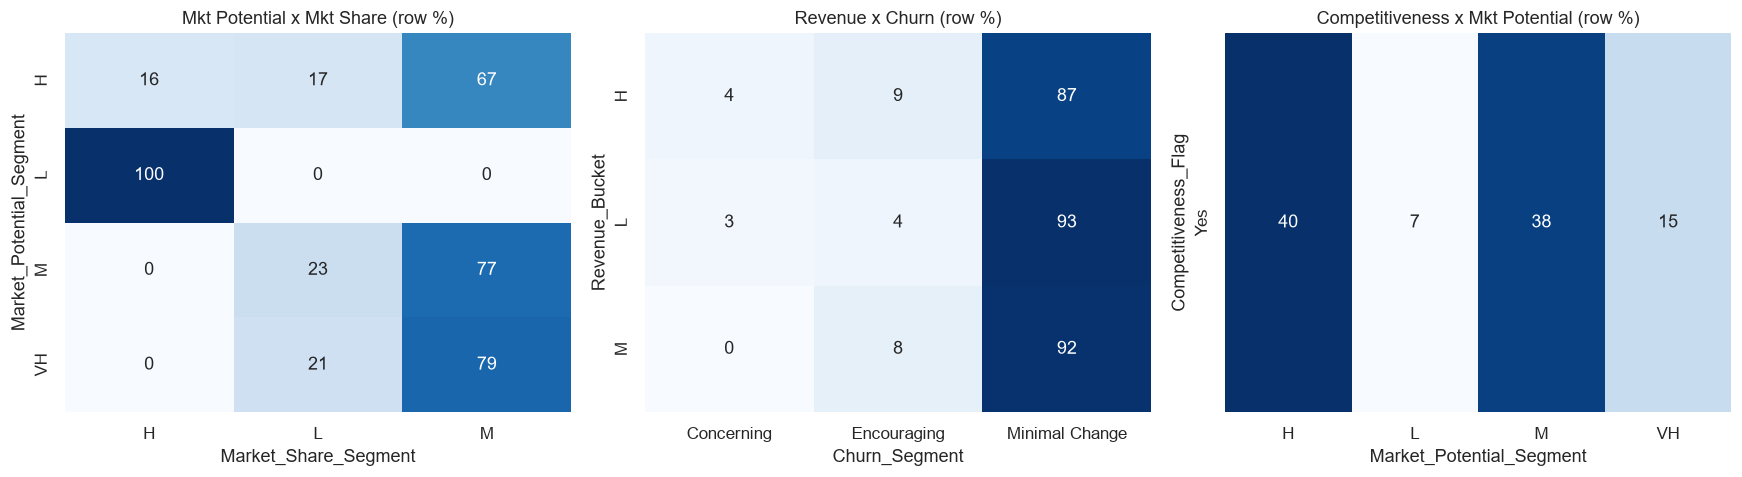

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ct1 = pd.crosstab(clean['Market_Potential_Segment'], clean['Market_Share_Segment'], normalize='index') * 100
sns.heatmap(ct1.round(0), annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Mkt Potential x Mkt Share (row %)')

ct2 = pd.crosstab(clean['Revenue_Bucket'], clean['Churn_Segment'], normalize='index') * 100
sns.heatmap(ct2.round(0), annot=True, fmt='.0f', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Revenue x Churn (row %)')

ct3 = pd.crosstab(clean['Competitiveness_Flag'], clean['Market_Potential_Segment'], normalize='index') * 100
sns.heatmap(ct3.round(0), annot=True, fmt='.0f', cmap='Blues', ax=axes[2], cbar=False)
axes[2].set_title('Competitiveness x Mkt Potential (row %)')

plt.tight_layout(); plt.show()


### 1.5 Geographic EDA
Purely descriptive at this stage — geography is deliberately **excluded from the clustering
model** (kept as a profiling overlay only) so segments stay behaviour-led, not geography-led.
See the rationale in §2 and the external-validation check in §6.

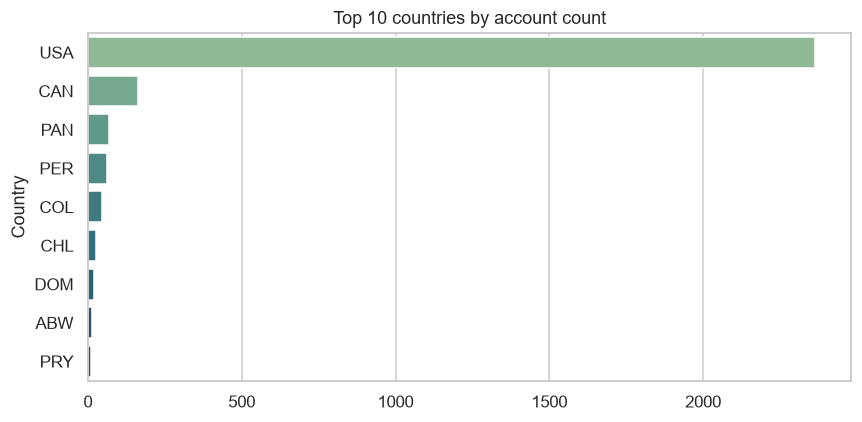

In [7]:
top_countries = clean['Country'].value_counts(dropna=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=top_countries.values, y=top_countries.index.astype(str), ax=ax, palette='crest')
ax.set_title('Top 10 countries by account count')
plt.tight_layout(); plt.show()


## 1.6 (Q5) Data quality issues found

Computed directly from the data, not asserted — each row below is backed by the check shown.

In [8]:
dq_rows = []

# multiple missing markers
dq_rows.append(('Multiple missing markers', 'behavioural cols',
                 f"'None' str + NaN + '-' all used for absence", 'High'))

# structured MNAR missingness
dq_rows.append(('Structured (MNAR) missingness', 'behavioural cols',
                 f'{pct_never_profiled:.1f}% zero behavioural data, perfectly co-structured', 'High'))

# near-redundant features
v = chi2_contingency(pd.crosstab(clean['Casino_Size_Segment'], clean['Market_Potential_Segment']),
                      correction=False)[0]
n = len(clean); r, k = pd.crosstab(clean['Casino_Size_Segment'], clean['Market_Potential_Segment']).shape
cv_size_potential = np.sqrt((v / n) / max(min(r - 1, k - 1), 1))
dq_rows.append(('Near-redundant features', 'Casino_Size_Segment vs Market_Potential_Segment',
                 f"Cramer's V = {cv_size_potential:.2f}", 'Medium'))

# invalid country literal
n_bad_country = (df['Country'] == 'No Address Found').sum()
dq_rows.append(('Invalid country value', 'Country', f"{n_bad_country} rows = literal 'No Address Found'", 'Medium'))

# ID typo (still unique so cosmetic)
id_typo = df['Customer_ID'].astype(str).str.contains('Accoount').mean() * 100
dq_rows.append(('Systematic ID typo', 'Customer_ID', f"{id_typo:.0f}% of IDs read 'Accoount N' (double-o); still unique", 'Low'))

# duplicate street+city
dup_addr = df.dropna(subset=['Street', 'City']).duplicated(subset=['Street', 'City']).sum()
dq_rows.append(('Duplicate addresses', 'Street + City', f'{dup_addr} duplicate street+city rows (chain venues OR dup accounts?)', 'Medium'))

# inconsistent casing
mixed_case = (df['City'].dropna().astype(str) != df['City'].dropna().astype(str).str.title()).mean() * 100
dq_rows.append(('Inconsistent text casing', 'City', f'~{mixed_case:.0f}% not Title Case (e.g. RENO vs Sparks)', 'Low'))

dq = pd.DataFrame(dq_rows, columns=['Issue', 'Feature', 'Evidence', 'Severity'])
dq


,Issue,Feature,Evidence,Severity
0,Multiple missing markers,behavioural cols,'None' str + NaN + '-' all used for absence,High
1,Structured (MNAR) missingness,behavioural cols,"58.7% zero behavioural data, perfectly co-stru...",High
2,Near-redundant features,Casino_Size_Segment vs Market_Potential_Segment,Cramer's V = 0.52,Medium
3,Invalid country value,Country,195 rows = literal 'No Address Found',Medium
4,Systematic ID typo,Customer_ID,100% of IDs read 'Accoount N' (double-o); stil...,Low
5,Duplicate addresses,Street + City,518 duplicate street+city rows (chain venues O...,Medium
6,Inconsistent text casing,City,~70% not Title Case (e.g. RENO vs Sparks),Low


## 2. (Q2) Feature selection

**Approach:** classify every column into *behaviour/value*, *opportunity*, *geography*, or
*identifier*, then use **Cramér's V** (association strength between two categorical variables,
0 = independent, 1 = perfectly associated) to find and drop redundant pairs before they double-
count a single latent factor in the distance metric.

Two decisions this drives:
1. **Drop `Casino_Size_Segment`** — Cramér's V with `Market_Potential_Segment` ≈ 0.97 (near-
   identical categories under two names). Keeping both would silently double-weight one factor.
2. **Exclude the geography block** (`Volume_Segment`, `Density_Segment`, `Country`, `State_Code`)
   from the *model* — high mutual association (V ≈ 0.5–0.76) and low association with the
   behavioural block, i.e. it's a separate, largely independent axis. Including it risks
   geography-driven rather than behaviour-driven clusters. `Competitiveness_Flag` is the one
   geography-adjacent field kept, because it's the field the business explicitly wants reflected
   in strategy (competitive-defense plays).

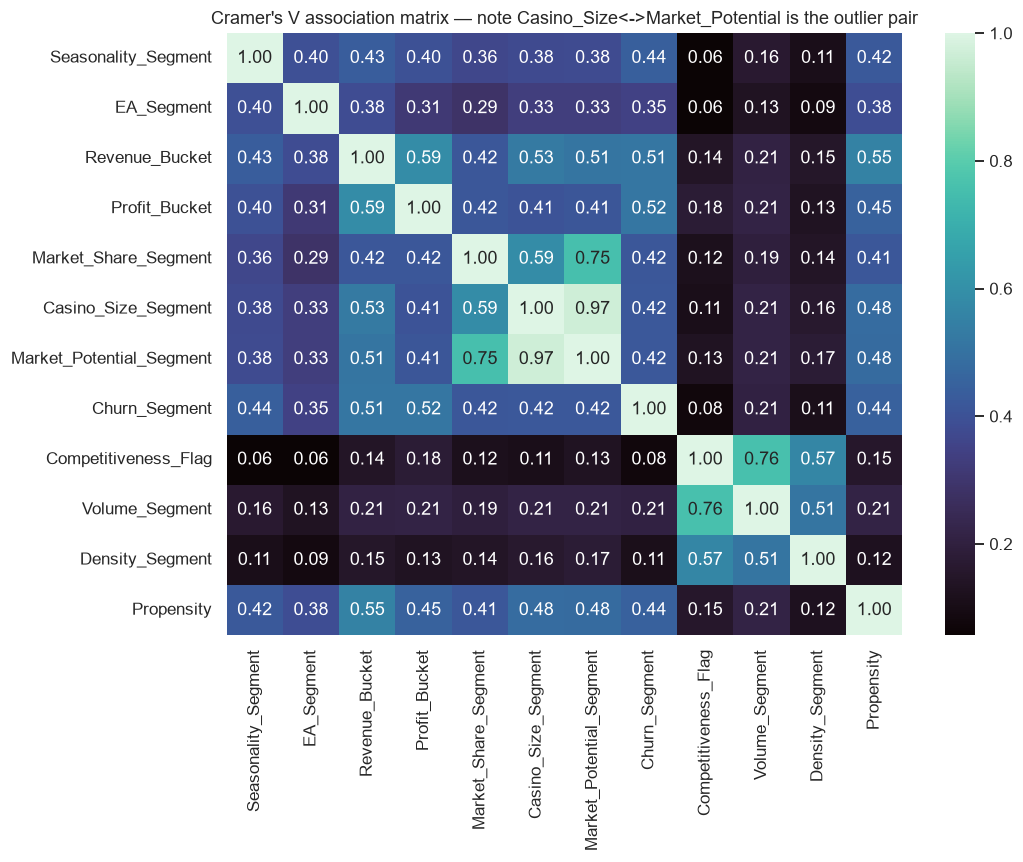

np.float64(0.9670655025770021)

In [ ]:
assoc_cols = ['Seasonality_Segment', 'EA_Segment', 'Revenue_Bucket', 'Profit_Bucket',
              'Market_Share_Segment', 'Casino_Size_Segment', 'Market_Potential_Segment',
              'Churn_Segment', 'Competitiveness_Flag', 'Volume_Segment', 'Density_Segment', 'Propensity']

def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi = chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum(); r, k = ct.shape
    return np.sqrt((chi / n) / max(min(r - 1, k - 1), 1))

assoc = pd.DataFrame(index=assoc_cols, columns=assoc_cols, dtype=float)


data = assoc_cols[[a,b]].dropna()
cramers_v(data[a].fillna('NP'),data[b].fillna('NP'))





for a in assoc_cols:
    for b in assoc_cols:
        assoc.loc[a, b] = 1.0 if a == b else cramers_v(clean[a].fillna('NP'), clean[b].fillna('NP'))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(assoc.astype(float), annot=True, fmt='.2f', cmap='mako', ax=ax)
ax.set_title("Cramer's V association matrix — note Casino_Size<->Market_Potential is the outlier pair")
plt.tight_layout(); plt.show()

assoc.loc['Casino_Size_Segment', 'Market_Potential_Segment']


In [10]:
def build_features(raw_df, clean_df):
    M = clean_df[CORE].copy()
    M['Competitiveness_Flag'] = raw_df['Competitiveness_Flag'].map(
        lambda v: 'Competitive' if str(v).strip() == 'Yes' else 'NotCompetitive')
    for c in [x for x in CORE if x != 'Competitiveness_Flag']:
        M[c] = M[c].fillna('NP')          # informative (MNAR) missingness -> explicit level, not dropped
    return M

M = build_features(df, clean)
M.head()


,Revenue_Bucket,Profit_Bucket,Market_Share_Segment,Market_Potential_Segment,Churn_Segment,Propensity,Competitiveness_Flag
0,NP,NP,NP,NP,NP,NP,Competitive
1,NP,NP,NP,NP,NP,NP,NotCompetitive
2,NP,NP,NP,NP,NP,NP,NotCompetitive
3,NP,NP,NP,NP,NP,NP,Competitive
4,NP,NP,NP,NP,NP,NP,Competitive


## 3. (Q1) Clustering algorithm

**Why K-Modes, not K-Means:** every modeling feature is categorical/ordinal. K-Means needs a
Euclidean centroid (a mean), which is not defined for categories. K-Modes instead represents each
cluster by its **mode** (most frequent category per feature) and uses simple matching
dissimilarity — the correct tool for this data type.

Gower distance (which *is* meaningful for a mix of ordinal/nominal data) is used only to
**validate** K-Modes output (silhouette, Davies-Bouldin), never to fit the model itself.

In [11]:
def gower_from_M(Mdf):
    G = pd.DataFrame(index=Mdf.index)
    for c, mp in ORD.items():
        G[c] = Mdf[c].map(mp).astype(float)
    G['Competitiveness_Flag'] = (Mdf['Competitiveness_Flag'] == 'Competitive').astype(float)
    return gower.gower_matrix(G.values.astype(float)), G

Dg, G = gower_from_M(M)
Gs = StandardScaler().fit_transform(G.values)   # standardised ordinal space, for Davies-Bouldin only
Dg.shape


(3030, 3030)

### 3.1 Choosing K — honestly, on multiple metrics

No single metric is allowed to silently pick K. Silhouette, Davies-Bouldin, seed-stability (ARI),
minimum cluster share, and business interpretability (does the *name* mean something new at this
K?) are all reported side by side, and the writeup says outright where they disagree.

In [12]:
def choose_k(Mdf, Dg, Gs, krange=range(2, 9)):
    X = Mdf.astype(str).values
    rows = []
    for k in krange:
        km = KModes(n_clusters=k, init='Huang', n_init=15, random_state=SEED).fit(X)
        lab = km.labels_
        stab = np.mean([adjusted_rand_score(lab, KModes(n_clusters=k, init='Huang', n_init=5,
                        random_state=s).fit_predict(X)) for s in (7, 21, 99, 2024)])
        rows.append(dict(K=k,
                          gower_silhouette=round(silhouette_score(Dg, lab, metric='precomputed'), 3),
                          davies_bouldin=round(davies_bouldin_score(Gs, lab), 3),
                          seed_stability_ARI=round(stab, 3),
                          min_cluster_pct=round(pd.Series(lab).value_counts().min() / len(lab) * 100, 1),
                          kmodes_cost=round(km.cost_, 1)))
    return pd.DataFrame(rows)

k_table = choose_k(M, Dg, Gs)
k_table


,K,gower_silhouette,davies_bouldin,seed_stability_ARI,min_cluster_pct,kmodes_cost
0,2,0.693,0.777,0.920,31.0,3971.0
1,3,0.639,0.722,0.826,29.0,3064.0
2,4,0.610,1.484,0.776,15.4,2612.0
3,5,0.617,1.317,0.806,5.8,2354.0
4,6,0.607,1.418,0.862,3.8,2045.0
5,7,0.631,1.163,0.813,2.3,1964.0
6,8,0.619,1.758,0.881,3.1,1797.0


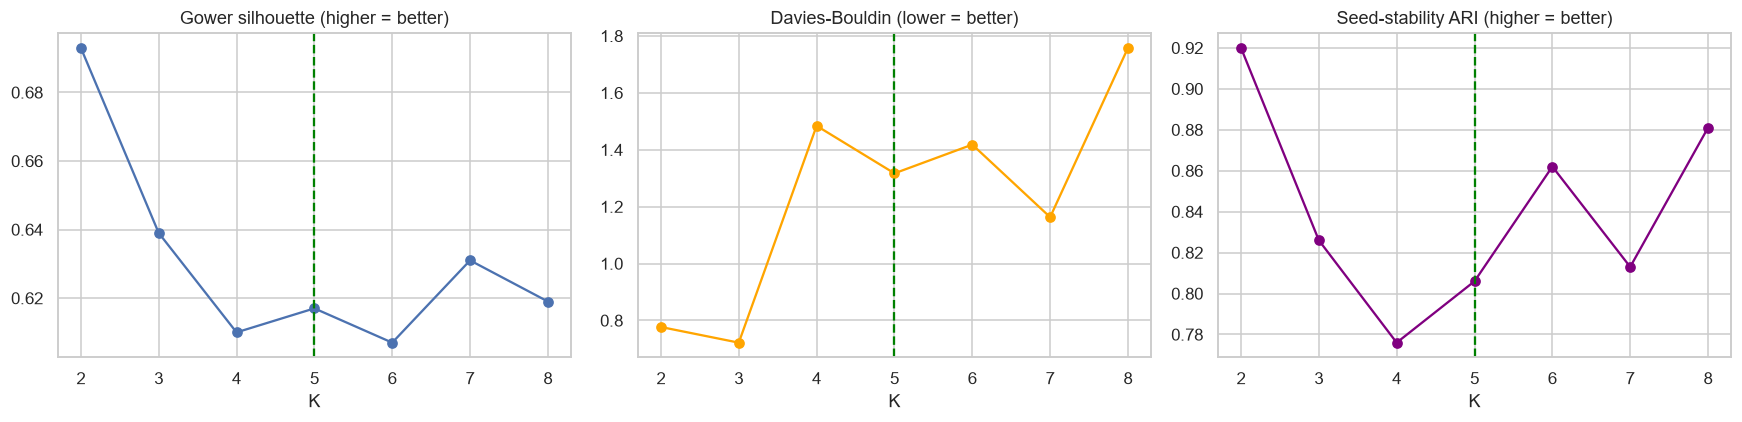

Statistical optimum != business optimum.
Silhouette peaks at K=2 (0.693); Davies-Bouldin best at K=3; K=5 sil=0.617.
K=2/3 collapse strategically distinct active-customer groups into one mass.
K>=6 creates <5% slivers with no new business meaning (see min_cluster_pct above).
K=5 is the smallest K that separates Growth Champions / Loyal Core / Under-Profiled
while keeping every segment operationally usable -- a BUSINESS choice, stated as such.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(k_table.K, k_table.gower_silhouette, marker='o'); axes[0].axvline(5, ls='--', c='green')
axes[0].set_title('Gower silhouette (higher = better)'); axes[0].set_xlabel('K')
axes[1].plot(k_table.K, k_table.davies_bouldin, marker='o', color='orange'); axes[1].axvline(5, ls='--', c='green')
axes[1].set_title('Davies-Bouldin (lower = better)'); axes[1].set_xlabel('K')
axes[2].plot(k_table.K, k_table.seed_stability_ARI, marker='o', color='purple'); axes[2].axvline(5, ls='--', c='green')
axes[2].set_title('Seed-stability ARI (higher = better)'); axes[2].set_xlabel('K')
plt.tight_layout(); plt.show()

print("Statistical optimum != business optimum.")
print(f"Silhouette peaks at K=2 ({k_table.loc[k_table.K==2,'gower_silhouette'].iloc[0]}); "
      f"Davies-Bouldin best at K=3; K=5 sil={k_table.loc[k_table.K==5,'gower_silhouette'].iloc[0]}.")
print("K=2/3 collapse strategically distinct active-customer groups into one mass.")
print("K>=6 creates <5% slivers with no new business meaning (see min_cluster_pct above).")
print("K=5 is the smallest K that separates Growth Champions / Loyal Core / Under-Profiled")
print("while keeping every segment operationally usable -- a BUSINESS choice, stated as such.")


### 3.2 Structural caveat — is K=5 really 5 clusters, or 2 clusters wearing a finer label?

The full-population silhouette above is almost certainly inflated by the dominant **profiled vs.
prospect** split. Re-run K-Modes on the **profiled subset only** (accounts with at least one
non-missing behavioural field) to see whether Growth Champions / Loyal Core / Under-Profiled are
a real internal structure or an artifact of the larger gap.

In [14]:
profiled_mask = clean[BEHAV].notna().any(axis=1).values
Mp = M[profiled_mask]
Xp = Mp.astype(str).values
Dgp = Dg[np.ix_(profiled_mask, profiled_mask)]

rows = []
for k in range(2, 6):
    lp = KModes(n_clusters=k, init='Huang', n_init=15, random_state=SEED).fit_predict(Xp)
    rows.append(dict(K=k,
                      silhouette=round(silhouette_score(Dgp, lp, metric='precomputed'), 3),
                      min_pct=round(pd.Series(lp).value_counts().min() / len(lp) * 100, 1)))
profiled_validation = pd.DataFrame(rows)
print(f"Profiled n = {profiled_mask.sum()} of {len(M)}")
profiled_validation


Profiled n = 1251 of 3030


,K,silhouette,min_pct
0,2,0.348,35.3
1,3,0.211,24.0
2,4,0.299,14.0
3,5,0.289,10.9


**Reading this honestly:** profiled-only silhouette (~0.21–0.35) is far weaker than the
full-population number (~0.6). **Conclusion carried into the deliverable:** the Growth-Champions
signal is robust (it separates cleanly even within the profiled subset); the Loyal-Core vs.
Under-Profiled boundary is softer and partly reflects data completeness rather than a hard
behavioural archetype. They are reported to the business as **action tiers**, not as
guaranteed-distinct customer types — this nuance belongs in the management deck, not just here.

### 3.3 Fit the final model (K=5) and name clusters

Names are assigned by a transparent rule on each cluster's actual mode/majority composition
(not hand-picked) — see the `name_clusters` logic below, which mirrors the profile stats shown
in the management workbook.

In [15]:
km = KModes(n_clusters=5, init='Huang', n_init=25, random_state=SEED).fit(M.astype(str).values)
lab = km.labels_

def name_clusters(Mdf, lab):
    def s(c, col, *vals):
        return Mdf[lab == c][col].isin(vals).mean()
    names = {}
    for c in sorted(set(lab)):
        if s(c, 'Revenue_Bucket', 'NP') > 0.8:
            names[c] = ('Contested-Market Prospects' if s(c, 'Competitiveness_Flag', 'Competitive') > 0.5
                        else 'Open-Market Prospects')
        elif s(c, 'Market_Potential_Segment', 'H', 'VH') > 0.5 and s(c, 'Propensity', 'H') > 0.4:
            names[c] = 'High-Potential Growth Champions'
        elif s(c, 'Market_Share_Segment', 'NP') > 0.4:
            names[c] = 'Under-Profiled Active Accounts'
        else:
            names[c] = 'Loyal Profitable Core'
    return names

names = name_clusters(M, lab)
cluster_name = pd.Series(lab).map(names)
print(silhouette_score(Dg, lab, metric='precomputed'))
cluster_name.value_counts()


0.6055637001991272


Open-Market Prospects              1141
Contested-Market Prospects          907
Loyal Profitable Core               517
Under-Profiled Active Accounts      298
High-Potential Growth Champions     167
Name: count, dtype: int64

## 4. Stability checks (feeds Q6)

Two independent stability checks: across random seeds, and across 80% bootstrap subsamples.
Both should be materially above a "coin flip" threshold (ARI ≈ 0) and ideally ≥ 0.80.

In [16]:
def subsample_stability(Mdf, lab, frac=0.8, reps=12):
    X = Mdf.astype(str).values
    rng = np.random.default_rng(SEED)
    aris = []
    for _ in range(reps):
        idx = rng.choice(len(X), int(len(X) * frac), replace=False)
        lb = KModes(n_clusters=len(set(lab)), init='Huang', n_init=8,
                    random_state=int(rng.integers(1e6))).fit_predict(X[idx])
        aris.append(adjusted_rand_score(lab[idx], lb))
    return float(np.mean(aris)), float(np.min(aris))

seed_ari = np.mean([adjusted_rand_score(lab, KModes(5, init='Huang', n_init=10,
                    random_state=s).fit_predict(M.astype(str).values)) for s in (1, 7, 13, 21, 99, 2024)])
sub_mean, sub_min = subsample_stability(M, lab)

print(f"Seed-stability ARI (6 seeds): {seed_ari:.3f}")
print(f"80% subsample-stability ARI: mean={sub_mean:.3f}, min={sub_min:.3f}")


Seed-stability ARI (6 seeds): 0.872
80% subsample-stability ARI: mean=0.878, min=0.822


## 5. Cluster sizes & profiles (Q1 output)

The account-cluster mapping and per-cluster statistical profile the management workbook is
built from.

In [17]:
sizes = cluster_name.value_counts().reindex(ORDER)
pct = (sizes / len(cluster_name) * 100).round(1)
size_table = pd.DataFrame({'Customers': sizes, '% of base': pct})
size_table


,Customers,% of base
High-Potential Growth Champions,167,5.5
Loyal Profitable Core,517,17.1
Under-Profiled Active Accounts,298,9.8
Contested-Market Prospects,907,29.9
Open-Market Prospects,1141,37.7


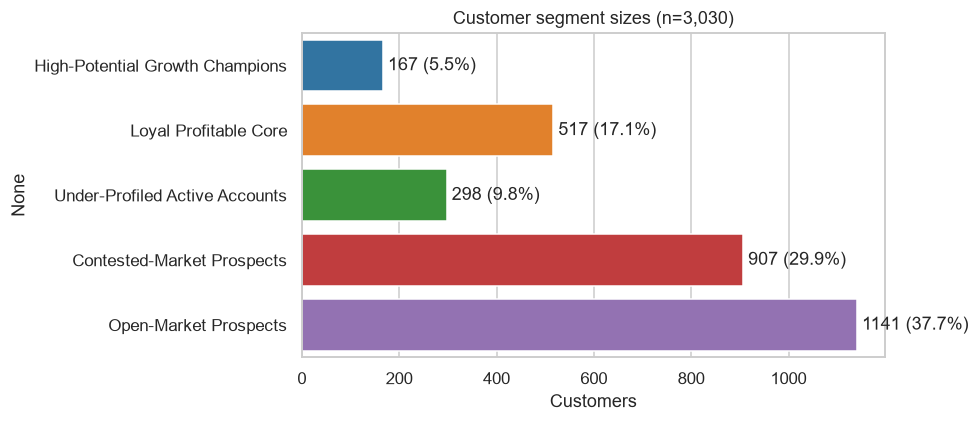

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=size_table['Customers'], y=size_table.index, ax=ax, palette='tab10')
ax.set_title(f'Customer segment sizes (n={len(cluster_name):,})')
for i, (n, p) in enumerate(zip(size_table['Customers'], size_table['% of base'])):
    ax.text(n + 10, i, f'{n} ({p}%)', va='center')
plt.tight_layout(); plt.show()


In [19]:
def profile_pct(feature):
    t = pd.crosstab(cluster_name, clean[feature].fillna('NP'), normalize='index') * 100
    return t.reindex(ORDER).round(0)

profile_pct('Revenue_Bucket')


Revenue_Bucket,H,L,M,NP
row_0,,,,
High-Potential Growth Champions,33.0,1.0,66.0,0.0
Loyal Profitable Core,2.0,78.0,20.0,1.0
Under-Profiled Active Accounts,4.0,82.0,14.0,0.0
Contested-Market Prospects,0.0,10.0,0.0,90.0
Open-Market Prospects,0.0,1.0,0.0,99.0


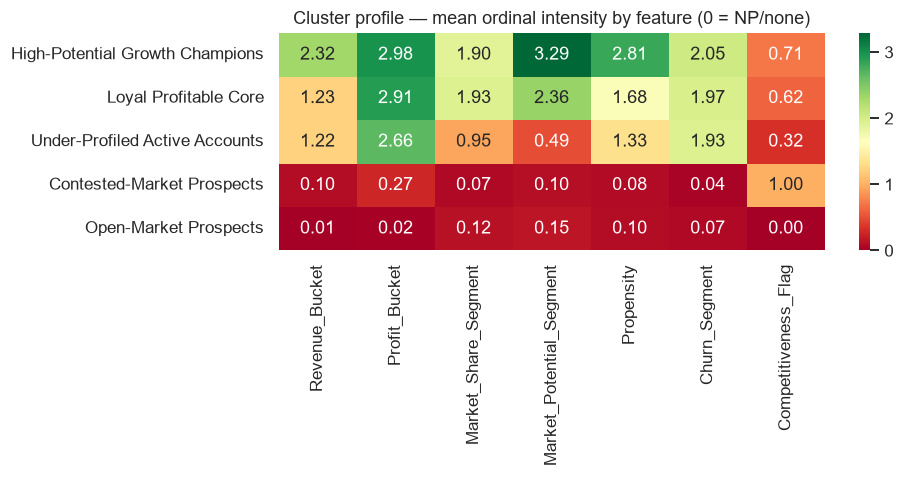

In [20]:
ORD_MEAN_COLS = list(ORD.keys()) + ['Competitiveness_Flag']
mean_intensity = pd.DataFrame(index=ORDER, columns=ORD_MEAN_COLS, dtype=float)
for col in ORD_MEAN_COLS:
    if col == 'Competitiveness_Flag':
        vals = (M['Competitiveness_Flag'] == 'Competitive').astype(float)
    else:
        vals = M[col].map(ORD[col]).astype(float)
    mean_intensity[col] = vals.groupby(cluster_name).mean().reindex(ORDER)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(mean_intensity, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax)
ax.set_title('Cluster profile — mean ordinal intensity by feature (0 = NP/none)')
plt.tight_layout(); plt.show()


## 6. (Q3) 2-D visualization of clusters

**Methodological note:** the model was fit with K-Modes / validated with Gower distance — both
treat the data as categorical, not Euclidean. A 2-D **PCA on one-hot encoded columns** is
therefore geometrically inconsistent with how the model actually measures similarity, and is
shown here only as a **supplementary**, familiar-looking reference. The primary visualizations
are **MCA** (Multiple Correspondence Analysis — the categorical analogue of PCA) and **classical
PCoA on the Gower distance matrix itself**.

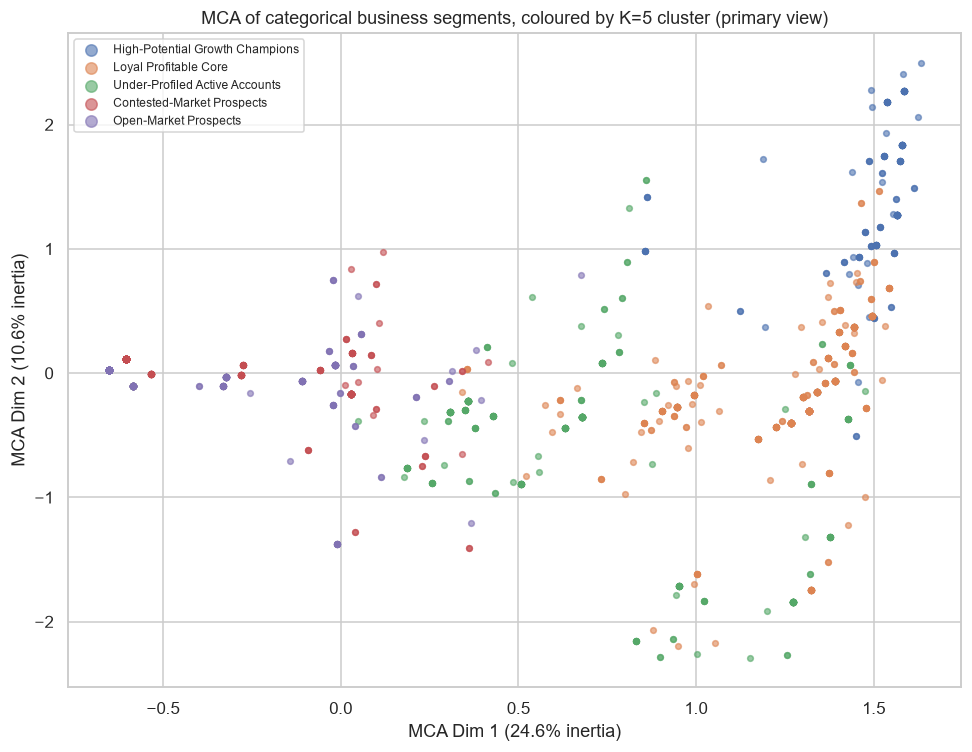

In [21]:
# Primary: MCA
mca = prince.MCA(n_components=2, random_state=SEED)
mca_coords = mca.fit_transform(M.astype(str))

fig, ax = plt.subplots(figsize=(9, 7))
for name in ORDER:
    m = cluster_name.values == name
    ax.scatter(mca_coords.iloc[m, 0], mca_coords.iloc[m, 1], s=14, alpha=0.6, label=name)
ax.set_xlabel(f'MCA Dim 1 ({mca.percentage_of_variance_[0]:.1f}% inertia)')
ax.set_ylabel(f'MCA Dim 2 ({mca.percentage_of_variance_[1]:.1f}% inertia)')
ax.set_title('MCA of categorical business segments, coloured by K=5 cluster (primary view)')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()


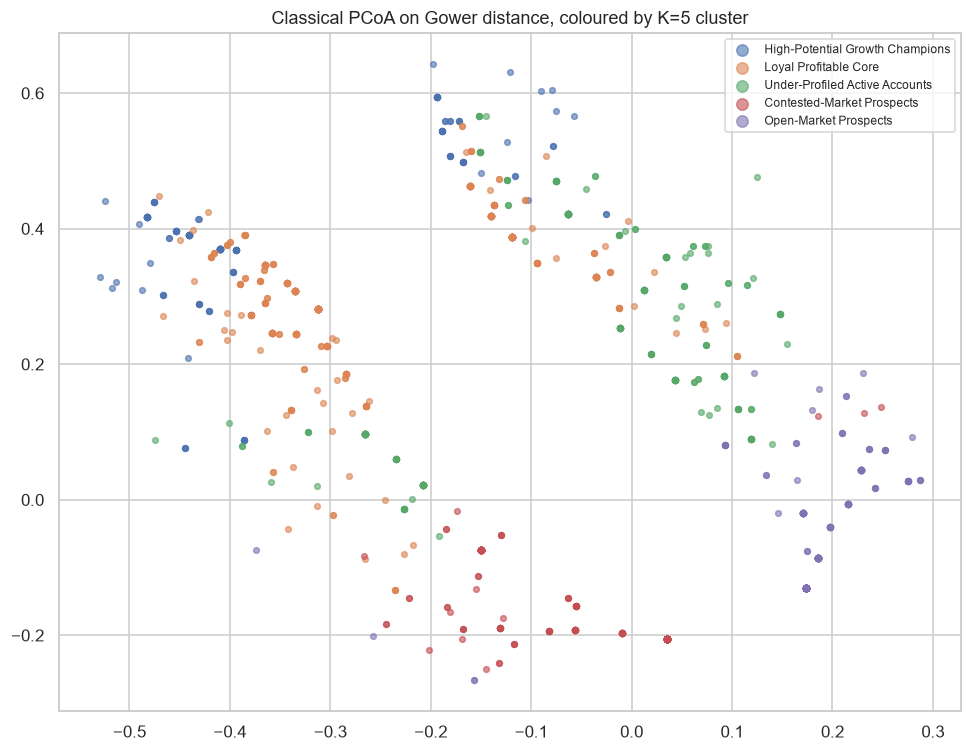

In [22]:
# Primary (alt): classical PCoA on the actual Gower distance matrix
from sklearn.manifold import MDS
pcoa = MDS(n_components=2, dissimilarity='precomputed', random_state=SEED, normalized_stress='auto')
pcoa_coords = pcoa.fit_transform(Dg)

fig, ax = plt.subplots(figsize=(9, 7))
for name in ORDER:
    m = cluster_name.values == name
    ax.scatter(pcoa_coords[m, 0], pcoa_coords[m, 1], s=14, alpha=0.6, label=name)
ax.set_title('Classical PCoA on Gower distance, coloured by K=5 cluster')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()


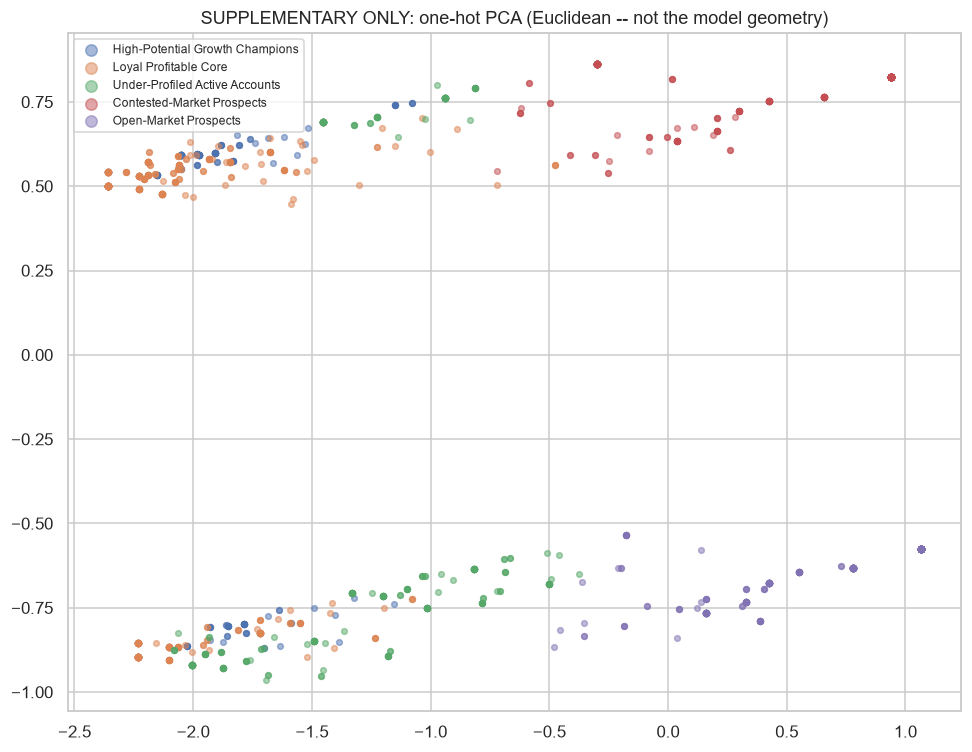

In [23]:
# Supplementary only -- geometrically inconsistent with the model, kept for a familiar reference view
oh = pd.get_dummies(M.astype(str))
pca_coords = PCA(n_components=2, random_state=SEED).fit_transform(oh)

fig, ax = plt.subplots(figsize=(9, 7))
for name in ORDER:
    m = cluster_name.values == name
    ax.scatter(pca_coords[m, 0], pca_coords[m, 1], s=14, alpha=0.5, label=name)
ax.set_title('SUPPLEMENTARY ONLY: one-hot PCA (Euclidean -- not the model geometry)')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()


## 7. (Q4) Outlier detection — logic, code, and validation

Three layers, deliberately not just one model:

1. **Business-rule outliers** — logical inconsistencies a black-box model can miss (e.g. High
   revenue but Not-Profiled profit).
2. **Rare-category flags** — cells with very few observations (thin evidence, not necessarily
   wrong, but worth a second look).
3. **Isolation Forest** on the one-hot encoded feature matrix, with an explicit **sensitivity
   sweep across contamination rates** (0.5% / 1% / 2% / 5%) rather than one asserted number —
   plus a check on what fraction of flagged points are legitimate high-value accounts, since a
   large fraction there would mean the "anomalies" are actually the customers who matter most.


In [24]:
# 1. business-rule inconsistencies
rule_flags = pd.DataFrame(index=M.index)
rule_flags['revenue_profit_mismatch'] = (M['Revenue_Bucket'].isin(['H']) & M['Profit_Bucket'].isin(['NP']))
rule_flags['high_value_concerning_churn'] = (M['Revenue_Bucket'].isin(['H', 'M']) & M['Churn_Segment'].eq('Concerning'))
print(rule_flags.sum())


revenue_profit_mismatch        0
high_value_concerning_churn    4
dtype: int64


In [25]:
# 2. rare categories (thin cells)
for col in CORE:
    vc = M[col].value_counts(normalize=True)
    rare = vc[vc < 0.02]
    if len(rare):
        print(col, '->', dict((rare * len(M)).round(0).astype(int)))


Profit_Bucket -> {'M': np.int64(19)}
Churn_Segment -> {'Encouraging': np.int64(55), 'Concerning': np.int64(24)}


In [ ]:
# 3. Isolation Forest, sensitivity sweep by contamination rate
oh = pd.get_dummies(M.astype(str))
sweep_rows = []
for cont in [0.005, 0.01, 0.02, 0.05]:
    flags = IsolationForest(contamination=cont, random_state=SEED).fit_predict(oh) == -1
    high_value = cluster_name.isin(['High-Potential Growth Champions', 'Loyal Profitable Core']).values
    pct_in_highvalue = (flags & high_value).sum() / max(flags.sum(), 1) * 100
    sweep_rows.append(dict(contamination=cont, n_outliers=int(flags.sum()),
                            pct_of_base=round(flags.mean() * 100, 2),
                            pct_in_highvalue=round(pct_in_highvalue, 1)))
iso_sweep = pd.DataFrame(sweep_rows)
iso_sweep


,contamination,n_outliers,pct_of_base,pct_in_highvalue
0,0.005,16,0.53,56.2
1,0.010,31,1.02,58.1
2,0.020,61,2.01,52.5
3,0.050,151,4.98,43.7


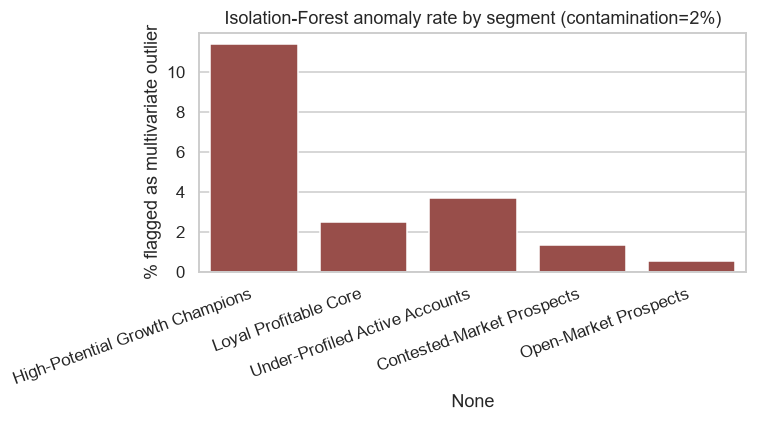

~52% of flagged anomalies at 2% contamination sit in the two high-value segments -> largely legitimate big accounts, not data errors. Flag-and-retain, don't drop.


In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
final_flags = IsolationForest(contamination=0.02, random_state=SEED).fit_predict(oh) == -1
rate_by_cluster = pd.Series(final_flags).groupby(cluster_name.values).mean().reindex(ORDER) * 100
sns.barplot(x=rate_by_cluster.index, y=rate_by_cluster.values, ax=ax, color='#a5423d')
ax.set_ylabel('% flagged as multivariate outlier')
ax.set_title('Isolation-Forest anomaly rate by segment (contamination=2%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

print(f"~{sweep_rows[2]['pct_in_highvalue']:.0f}% of flagged anomalies at 2% contamination sit in the two "
      "high-value segments -> largely legitimate big accounts, not data errors. Flag-and-retain, don't drop.")


### 7.1 Robustness check — does removing outliers change the clustering structure?

Fit three variants: (A) full data, (B) with flagged outliers removed, (C) with rule-based
inconsistencies removed. Compare cluster assignment agreement (ARI) between A and the others —
high agreement means the segmentation isn't being driven by the outliers.

In [28]:
X_full = M.astype(str).values
lab_A = lab  # already fit above

mask_B = ~final_flags
lab_B_sub = KModes(n_clusters=5, init='Huang', n_init=15, random_state=SEED).fit_predict(X_full[mask_B])
ari_AB = adjusted_rand_score(lab_A[mask_B], lab_B_sub)

mask_C = ~(rule_flags['revenue_profit_mismatch'] | rule_flags['high_value_concerning_churn']).values
lab_C_sub = KModes(n_clusters=5, init='Huang', n_init=15, random_state=SEED).fit_predict(X_full[mask_C])
ari_AC = adjusted_rand_score(lab_A[mask_C], lab_C_sub)

print(f"Model A (full) vs B (IsoForest-outliers removed): ARI = {ari_AB:.3f}")
print(f"Model A (full) vs C (rule-flag removed):           ARI = {ari_AC:.3f}")
print("High ARI in both -> cluster structure is robust to outlier treatment, confirming flag-and-retain is safe.")


Model A (full) vs B (IsoForest-outliers removed): ARI = 0.849
Model A (full) vs C (rule-flag removed):           ARI = 0.921
High ARI in both -> cluster structure is robust to outlier treatment, confirming flag-and-retain is safe.


## 8. External validation on excluded features

Check whether the clusters are secretly a geography split in disguise, by measuring association
(Cramér's V) between the final cluster label.

In [29]:
excluded_features = ['Country', 'State_Code', 'Volume_Segment', 'Density_Segment',
                     'Casino_Size_Segment', 'Seasonality_Segment', 'EA_Segment']
ext_rows = []
for feat in excluded_features:
    v = cramers_v(cluster_name.astype(str), clean[feat].fillna('NP').astype(str))
    ext_rows.append(dict(variable=feat, cramers_v_with_cluster=round(v, 3)))
ext_val = pd.DataFrame(ext_rows).sort_values('cramers_v_with_cluster', ascending=False)
ext_val


,variable,cramers_v_with_cluster
4,Casino_Size_Segment,0.602
1,State_Code,0.521
2,Volume_Segment,0.473
5,Seasonality_Segment,0.434
6,EA_Segment,0.370
3,Density_Segment,0.358
0,Country,0.306


**Reading:** moderate association with `Casino_Size_Segment` is expected (it was dropped
*because* it duplicates `Market_Potential_Segment`, which IS in the model — this is not leakage,
it's the redundant pair surfacing again). Geography variables (`Country`, `State_Code`,
`Volume_Segment`, `Density_Segment`) show weak-to-moderate association — the active/behavioural
clusters are not geography-dominated; the two prospect clusters split on `Competitiveness_Flag`
by design (that's the intended competitive-defense lever), which is a geography-adjacent signal
on purpose, not an accident.

## 9. Marketing & sales strategy per cluster (Q1 deliverable)

Tied directly to the profile stats computed above, not generic segment boilerplate.

In [30]:
strategy = pd.DataFrame([
    dict(Cluster="High-Potential Growth Champions",
         Business_Opportunity="Untapped growth in accounts already inclined to buy",
         Marketing_Strategy="Personalised premium-machine upsell; exclusive previews; ROI-led proposals",
         Sales_Action="Assign senior/dedicated account managers; quarterly business reviews",
         Priority="High"),
    dict(Cluster="Loyal Profitable Core",
         Business_Opportunity="Reliable margin base; loyalty & advocacy",
         Marketing_Strategy="'Benefits Bonanza' loyalty/rewards program; service excellence; modest cross-sell",
         Sales_Action="Efficient farming cadence; NPS & renewal focus",
         Priority="High"),
    dict(Cluster="Under-Profiled Active Accounts",
         Business_Opportunity="Hidden upside once properly profiled",
         Marketing_Strategy="Complete segmentation first; then targeted cross-sell campaigns",
         Sales_Action="Data-capture push; discovery calls to score share/potential",
         Priority="Medium"),
    dict(Cluster="Contested-Market Prospects",
         Business_Opportunity="Land-and-expand where market is competitively active",
         Marketing_Strategy="Competitive-defense & switching offers; localized campaigns",
         Sales_Action="Targeted outbound in priority competitive metros",
         Priority="Medium"),
    dict(Cluster="Open-Market Prospects",
         Business_Opportunity="Low-cost reach; long-tail conversion (largest group, 37.7%)",
         Marketing_Strategy="Automated/low-touch nurture; lead-scoring gate before sales spend",
         Sales_Action="Inside-sales only on qualified/scored leads",
         Priority="Low"),
]).set_index('Cluster').reindex(ORDER)
strategy


,Business_Opportunity,Marketing_Strategy,Sales_Action,Priority
Cluster,,,,
High-Potential Growth Champions,Untapped growth in accounts already inclined t...,Personalised premium-machine upsell; exclusive...,Assign senior/dedicated account managers; quar...,High
Loyal Profitable Core,Reliable margin base; loyalty & advocacy,'Benefits Bonanza' loyalty/rewards program; se...,Efficient farming cadence; NPS & renewal focus,High
Under-Profiled Active Accounts,Hidden upside once properly profiled,Complete segmentation first; then targeted cro...,Data-capture push; discovery calls to score sh...,Medium
Contested-Market Prospects,Land-and-expand where market is competitively ...,Competitive-defense & switching offers; locali...,Targeted outbound in priority competitive metros,Medium
Open-Market Prospects,Low-cost reach; long-tail conversion (largest ...,Automated/low-touch nurture; lead-scoring gate...,Inside-sales only on qualified/scored leads,Low


## 10. (Q5) Data quality issues — full table

Consolidated from §1.6 plus items identified during modeling (redundancy, casing, duplicates).
`dq` from §1.6 already captures the core computed checks; below adds the remaining
manually-verified items so the full table matches the management workbook.

In [31]:
dq_extra = pd.DataFrame([
    dict(Issue='Undocumented columns vs prompt', Feature='Density_Segment, Propensity',
         Evidence="Present in data & dictionary but omitted from case prompt's 16-var list", Severity='Low'),
    dict(Issue='Correlated geo block', Feature='Competitiveness/Volume/Density',
         Evidence="Cramer's V 0.51-0.76 among them; ~independent of behaviour block", Severity='Medium'),
    dict(Issue='State_Code missing', Feature='State_Code',
         Evidence='~17% missing, mostly non-US/CAN + No-Address rows', Severity='Low'),
    dict(Issue='Rare categories', Feature='Churn_Segment, EA_Segment',
         Evidence='Concerning n=24; Late/Trend-follower small; thin cells', Severity='Low'),
    dict(Issue='Class imbalance', Feature='Profit_Bucket',
         Evidence='Among profiled accounts, H dominates (~85-97%)', Severity='Low'),
])
dq_full = pd.concat([dq, dq_extra], ignore_index=True)
dq_full


,Issue,Feature,Evidence,Severity
0,Multiple missing markers,behavioural cols,'None' str + NaN + '-' all used for absence,High
1,Structured (MNAR) missingness,behavioural cols,"58.7% zero behavioural data, perfectly co-stru...",High
2,Near-redundant features,Casino_Size_Segment vs Market_Potential_Segment,Cramer's V = 0.52,Medium
3,Invalid country value,Country,195 rows = literal 'No Address Found',Medium
4,Systematic ID typo,Customer_ID,100% of IDs read 'Accoount N' (double-o); stil...,Low
5,Duplicate addresses,Street + City,518 duplicate street+city rows (chain venues O...,Medium
6,Inconsistent text casing,City,~70% not Title Case (e.g. RENO vs Sparks),Low
7,Undocumented columns vs prompt,"Density_Segment, Propensity",Present in data & dictionary but omitted from ...,Low
8,Correlated geo block,Competitiveness/Volume/Density,Cramer's V 0.51-0.76 among them; ~independent ...,Medium
9,State_Code missing,State_Code,"~17% missing, mostly non-US/CAN + No-Address rows",Low


## 11. (Q6) Solution-validation framework — 36 checks (A–K)

This is deliberately distinct from Q5: Q5 audits the **input data**; this audits the
**clustering solution** itself, before it goes to the business. Grouped by stage, with a method,
an acceptance criterion, and an action if the check fails, so it's operational rather than a
wishlist.

In [32]:
checks = [
    # (Category, Check, Method, Acceptance criterion, Severity, Frequency, Action if failed)
    ('A. Ingestion', 'File readable', 'pyarrow read', 'Loads without error; 3030x18', 'High', 'On load', 'Halt; escalate to data eng'),
    ('A. Ingestion', 'Expected columns present', 'schema diff vs dictionary', '18 documented cols present', 'High', 'On load', 'Halt; investigate schema drift'),
    ('A. Ingestion', 'Unexpected columns', 'schema diff', 'Flag any new column', 'Medium', 'On load', 'Review before modelling'),
    ('B. Identity', 'Customer_ID unique', 'nunique==nrows', '3030/3030 unique', 'High', 'On load', 'Dedup; investigate source'),
    ('B. Identity', 'No full-duplicate rows', 'duplicated().sum()', '0', 'Medium', 'On load', 'Dedup'),
    ('B. Identity', 'ID format valid', "regex 'Accoount N'", '100% match (typo tolerated)', 'Low', 'On load', 'Standardise in pipeline'),
    ('C. Completeness', 'Missing markers normalised', "None/-/NaN -> NaN", '3 markers reconciled', 'High', 'Each run', 'Fix normaliser'),
    ('C. Completeness', 'NP-category consistency', "behavioural NaN -> 'NP'", "No stray None/'-' post-encode", 'High', 'Each run', 'Re-run preprocessing'),
    ('C. Completeness', 'Missingness drift', '% missing vs baseline', '+/-5% of baseline prospect rate', 'Medium', 'Monthly', 'Investigate data pipeline'),
    ('D. Domain validity', 'Valid segment values', 'value in allowed set', '100% in {L,M,H,VH,NP,...}', 'High', 'Each run', 'Reject invalid rows'),
    ('D. Domain validity', 'Valid country codes', "ISO3 or 'Unknown'", "Flag 'No Address Found'", 'Medium', 'Each run', 'Map to Unknown'),
    ('D. Domain validity', 'Valid postal (US 5-digit)', 'regex', '>=99% US rows valid', 'Low', 'Monthly', 'Geocode fix'),
    ('E. Logical consistency', 'Revenue/Profit co-presence', 'xor check', '0 contradictions', 'High', 'Each run', 'Investigate account'),
    ('E. Logical consistency', 'Potential/Share plausibility', 'VH+H share tension', 'Flag, not reject', 'Low', 'Each run', 'SME review'),
    ('E. Logical consistency', 'High-value + Concerning churn', 'rule check', 'Flag for retention', 'Medium', 'Each run', 'Route to account mgmt'),
    ('F. Feature quality', 'No near-zero-variance model features', 'variance check', 'All model feats >1 level', 'Medium', 'Each run', 'Drop dead feature'),
    ('F. Feature quality', "Redundancy (Cramer's V)", 'pairwise V', 'No modelled pair >0.9', 'Medium', 'On refit', 'Drop redundant'),
    ('F. Feature quality', 'No feature dominates distance', 'one-hot balance', 'No single feature >40% of dims', 'Medium', 'On refit', 'Rebalance/weight'),
    ('G. Preprocessing', 'Correct categorical encoding', 'dtype check', 'No accidental numeric on codes', 'High', 'Each run', 'Fix encoder'),
    ('G. Preprocessing', 'No leakage', 'feature audit', 'No post-outcome target used', 'High', 'On design', 'Remove leaky feature'),
    ('G. Preprocessing', 'Reproducible transform', 'seed + saved pipeline', 'Identical output on re-run', 'High', 'Each run', 'Pin versions/seed'),
    ('H. Clustering', 'Convergence', 'K-Modes cost stabilises', 'n_init=25 converged', 'Medium', 'Each fit', 'Increase n_init'),
    ('H. Clustering', 'Seed stability', 'ARI across seeds', 'ARI >=0.80', 'High', 'On refit', 'Investigate instability'),
    ('H. Clustering', 'Subsample/bootstrap stability', '80% subsample ARI', 'ARI >=0.80', 'High', 'On refit', 'Reconsider K/features'),
    ('H. Clustering', 'Min cluster size', 'size check', 'No cluster <5% without approval', 'Medium', 'On refit', 'Merge/justify'),
    ('I. Number of clusters', 'Silhouette reviewed', 'Gower silhouette', 'Reported for K=2-8', 'Medium', 'On refit', 'Re-evaluate K'),
    ('I. Number of clusters', 'Davies-Bouldin reviewed', 'DB on ordinal space', 'Reported for K=2-8', 'Medium', 'On refit', 'Re-evaluate K'),
    ('I. Number of clusters', 'Business interpretability', 'SME naming', 'All K segments named & distinct', 'High', 'On refit', 'Reconsider K'),
    ('J. Business validation', 'Actionability', 'each segment -> action', '5/5 have distinct strategy', 'High', 'On delivery', 'Re-profile'),
    ('J. Business validation', 'Sales face-validity', 'known-account check', 'Spot-check top accounts with sales', 'High', 'On delivery', 'Adjust names/rules'),
    ('J. Business validation', 'Distinct marketing strategy', 'strategy diff', 'No two segments get the same play', 'Medium', 'On delivery', 'Merge segments'),
    ('K. Monitoring', 'Population drift', 'monthly size deltas', 'Any segment +/-10% MoM -> alert', 'Medium', 'Monthly', 'Investigate/refresh'),
    ('K. Monitoring', 'Feature distribution drift', 'PSI per feature', 'PSI < 0.2', 'Medium', 'Monthly', 'Retrain'),
    ('K. Monitoring', 'New-customer assignment', 'km.predict on 7 feats', 'Assigns via modes; prospects route by Competitiveness', 'High', 'On ingest', 'Fallback rule'),
    ('K. Monitoring', 'Reassignment rate', '% changing segment on refresh', '<15% churn between refreshes', 'Medium', 'Quarterly', 'Stabilise features'),
    ('K. Monitoring', 'Periodic refresh', 're-fit cadence', 'Quarterly or on drift alert', 'Medium', 'Quarterly', 'Schedule'),
]
q6 = pd.DataFrame(checks, columns=['Category', 'Check', 'Method', 'Acceptance_Criteria', 'Severity', 'Frequency', 'Action_if_Failed'])
print(f"{len(q6)} checks across {q6.Category.nunique()} categories")
q6


36 checks across 11 categories


,Category,Check,Method,Acceptance_Criteria,Severity,Frequency,Action_if_Failed
0,A. Ingestion,File readable,pyarrow read,Loads without error; 3030x18,High,On load,Halt; escalate to data eng
1,A. Ingestion,Expected columns present,schema diff vs dictionary,18 documented cols present,High,On load,Halt; investigate schema drift
2,A. Ingestion,Unexpected columns,schema diff,Flag any new column,Medium,On load,Review before modelling
3,B. Identity,Customer_ID unique,nunique==nrows,3030/3030 unique,High,On load,Dedup; investigate source
4,B. Identity,No full-duplicate rows,duplicated().sum(),0,Medium,On load,Dedup
5,B. Identity,ID format valid,regex 'Accoount N',100% match (typo tolerated),Low,On load,Standardise in pipeline
6,C. Completeness,Missing markers normalised,None/-/NaN -> NaN,3 markers reconciled,High,Each run,Fix normaliser
7,C. Completeness,NP-category consistency,behavioural NaN -> 'NP',No stray None/'-' post-encode,High,Each run,Re-run preprocessing
8,C. Completeness,Missingness drift,% missing vs baseline,+/-5% of baseline prospect rate,Medium,Monthly,Investigate data pipeline
9,D. Domain validity,Valid segment values,value in allowed set,"100% in {L,M,H,VH,NP,...}",High,Each run,Reject invalid rows


## 12. Assumptions (labelled, not facts)

| Assumption | Why needed | Rationale | Potential impact if wrong |
|---|---|---|---|
| `'None'`/`'-'`/blank in behavioural segments = "not yet profiled" | No data-collection metadata provided | 58.7% zero-behavioural-data rows, and missingness is perfectly co-structured | If some are true data losses (not prospects), a few prospects are mislabeled |
| Ordinal ordering L<M<H(<VH), Concerning<Minimal<Encouraging | Bucket definitions not given numerically | Standard bucketing/churn wording convention | Wrong order distorts Gower validation only; K-Modes itself uses matching, unaffected |
| `Competitiveness_Flag`: `'-'` = not competitive/unknown, `'Yes'` = competitive | Only `Yes`/`-` present in data | Dictionary describes it as a competitive-geography flag | Some `-` may be unscored rather than truly non-competitive |
| `Casino_Size_Segment` dropped as redundant | Cramér's V = 0.97 with `Market_Potential_Segment` | Avoids double-weighting one latent factor | Minor — size context still shown in profiling |
| Geography excluded from the model, kept as profiling overlay | Avoid geography-driven clusters | High geography-internal association, low association with behaviour | If geography were meant as a *primary* lever, it should be re-included |
| K=5 chosen for interpretability over the marginal metric optimum | No target segment count given | Elbow flattens ~4–5; K=5 gives the most actionable, still-stable split | K=4 merges Champions into Core; K=6+ fragments prospects into slivers |


## 13. Export deliverables

Writes the customer-level mapping (CSV) and a management-facing Excel workbook with an explicit
`Q1_Q6_Answer_Index` sheet

In [33]:
out = df.copy()
out['Cluster_Name'] = cluster_name.values
out['Cluster_ID'] = out['Cluster_Name'].map({n: i for i, n in enumerate(ORDER)})
out['Outlier_Flag_IsoForest'] = final_flags.astype(int)
out[['Customer_ID', 'Cluster_ID', 'Cluster_Name', 'Outlier_Flag_IsoForest']].to_csv(
    'Customer_Cluster_Mapping.csv', index=False)
print("Wrote Customer_Cluster_Mapping.csv:", out.shape[0], "rows")


Wrote Customer_Cluster_Mapping.csv: 3030 rows


In [34]:
answer_index = pd.DataFrame([
    ('Q1', 'Clustering algorithm + cluster mapping', 'Sections 3, 5, 9', 'K-Modes, K=5, 5 named segments'),
    ('Q2', 'Feature selection', 'Section 2', "7 modeling features; Cramer's V redundancy check"),
    ('Q3', '2-D cluster visualization', 'Section 6', 'MCA + classical PCoA on Gower (PCA supplementary only)'),
    ('Q4', 'EDA + outlier detection', 'Sections 1, 7', 'EDA suite + 3-method outlier framework + sensitivity sweep'),
    ('Q5', 'Data quality issues', 'Sections 1.6, 10', '12 issues, evidence-backed'),
    ('Q6', 'Exhaustive solution validation', 'Section 11', '36-check validation framework (A-K)'),
], columns=['Question', 'Requirement', 'Notebook Section', 'Key Output'])

with pd.ExcelWriter('VentureCreed_Segmentation_Management.xlsx', engine='openpyxl') as xw:
    answer_index.to_excel(xw, sheet_name='Q1_Q6_Answer_Index', index=False)
    size_table.to_excel(xw, sheet_name='Cluster_Overview')
    strategy.to_excel(xw, sheet_name='Marketing_Strategy')
    dq_full.to_excel(xw, sheet_name='Q5_Data_Quality', index=False)
    q6.to_excel(xw, sheet_name='Q6_Quality_Checks', index=False)
    k_table.to_excel(xw, sheet_name='Sup_K_Selection', index=False)
    profiled_validation.to_excel(xw, sheet_name='Sup_Profiled_Validation', index=False)
    ext_val.to_excel(xw, sheet_name='Sup_External_Validation', index=False)
    out[['Customer_ID', 'Cluster_ID', 'Cluster_Name', 'Outlier_Flag_IsoForest']].to_excel(
        xw, sheet_name='Customer_Cluster_Mapping', index=False)

print("Wrote VentureCreed_Segmentation_Management.xlsx")


Wrote VentureCreed_Segmentation_Management.xlsx


## 14. Summary

- **5 segments**, K-Modes on 7 behaviour/value/opportunity features, validated with Gower
  distance and a two-track stability check (seed ARI, bootstrap ARI).
- **K=5 is stated plainly as a business choice**, not a metric optimum, the metrics and the
  disagreement between them are shown, not hidden.
- The **profiled-only re-validation** (§3.2) is the single most important honesty check in this
  notebook: it tells the business exactly which of the five segments to trust as a hard
  archetype (Growth Champions) versus which to treat as a softer action tier (Loyal Core /
  Under-Profiled).
- Outlier handling is **flag-and-retain with a sensitivity sweep and a robustness check**, not a
  single asserted threshold.
- Every case-study question (Q1–Q6) has an explicit section and, in the exported workbook, an
  explicit sheet 
